# Modelo de Pronóstico de Demanda — Propuesta para el cliente

**Equipo:** MetricEdge

## Contexto y problema de negocio

El sistema de recomendación personalizada exploró 6 enfoques distintos (filtrado colaborativo,
contenido, híbrido, afinidad por categoría, canasta de compra y retención de clientes) y en todos los
casos las variables de comportamiento individual no mostraron señal predictiva superior al azar.

Frente a ese resultado, se buscó una pregunta de negocio distinta que **sí** tuviera estructura real y
aprovechable en los datos: **¿cuánto va a vender el negocio el mes que viene?** El EDA ya había detectado
una estacionalidad marcada (picos en noviembre-diciembre); este notebook construye, valida rigurosamente
y deja lista para producción una **propuesta de pronóstico de demanda mensual**.

**Valor de negocio directo:**
- Planificación de inventario y compras con antelación.
- Dotación de personal ajustada a los picos de temporada alta.
- Presupuesto de marketing y flujo de caja proyectado con base cuantitativa.

**Contenido:**
1. Datos y estacionalidad
2. Comparación de 3 métodos de pronóstico
3. Validación robusta (backtesting con 3 ventanas históricas)
4. Modelo elegido y pronóstico por categoría
5. Pronóstico a futuro (próximos 12 meses) con banda de incertidumbre
6. Recomendaciones de negocio


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

def mape(y_true, y_pred):
    return np.mean(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / np.asarray(y_true))) * 100


## 1. Datos y estacionalidad

Serie mensual: 60 meses (2021-01 a 2025-12)


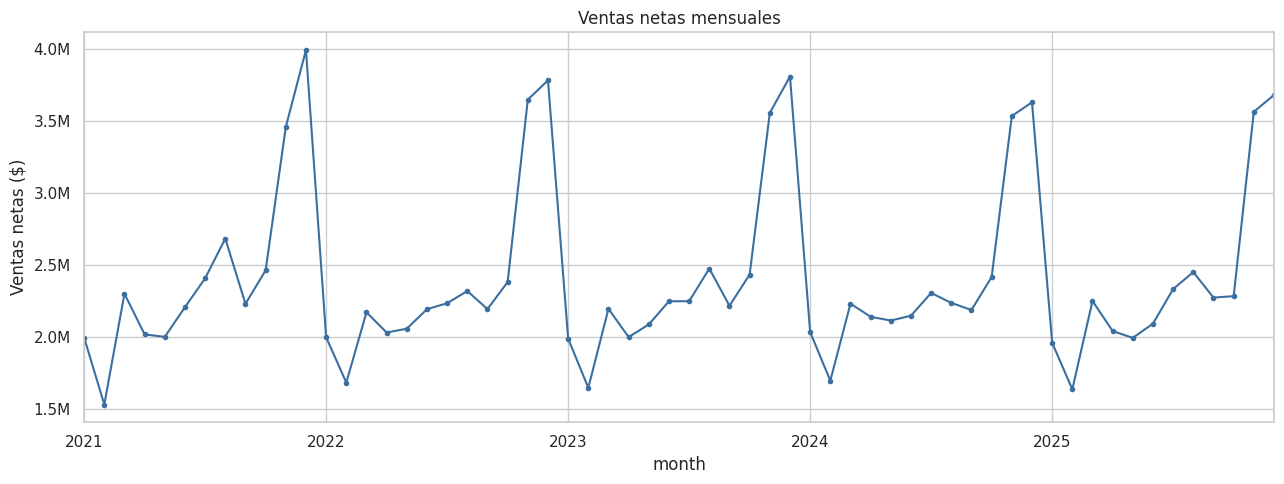

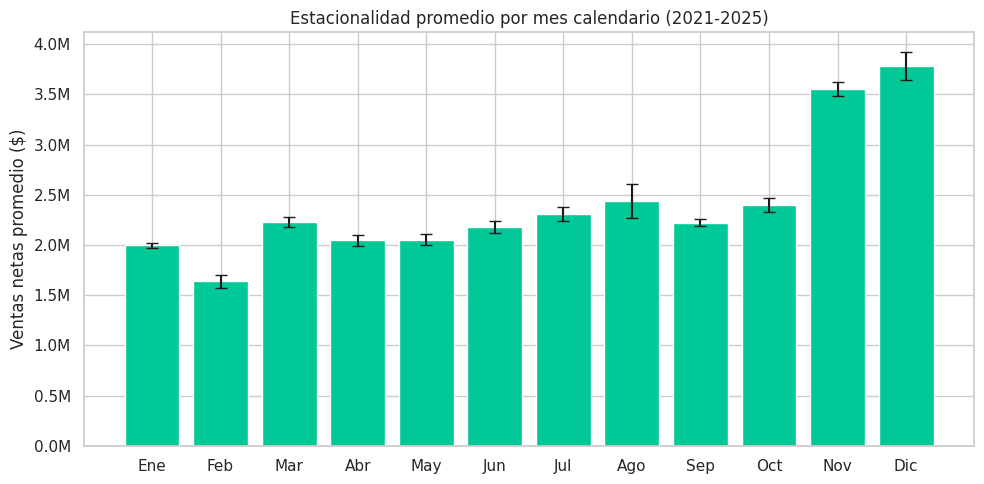

In [2]:
sales = pd.read_csv("../data/processed/sales_clean.csv", parse_dates=["order_date"])

# Filtro confirmado con el Product Owner: para el modelo de recomendacion de stock,
# solo las ordenes Completed cuentan como demanda real. Una devolucion puede deberse
# a multiples razones ajenas a la demanda (talla, calidad, expectativas), asi que no
# es una senal limpia para pronosticar volumen a reforzar en inventario.
sales = sales[sales["order_status"] == "Completed"].copy()

sales["month"] = sales["order_date"].dt.to_period("M")
monthly = sales.groupby("month")["net_sales"].sum().sort_index()
monthly.index = monthly.index.to_timestamp()

print(f"Serie mensual: {len(monthly)} meses ({monthly.index.min():%Y-%m} a {monthly.index.max():%Y-%m})")

fig, ax = plt.subplots(figsize=(13, 5))
monthly.plot(ax=ax, color="#3b6fa0", marker="o", markersize=3)
ax.set_title("Ventas netas mensuales")
ax.set_ylabel("Ventas netas ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

# Estacionalidad promedio por mes calendario
por_mes = monthly.groupby(monthly.index.month).agg(["mean", "std"])
por_mes.index = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(por_mes.index, por_mes["mean"], yerr=por_mes["std"], color="#00C896", capsize=4)
ax.set_title("Estacionalidad promedio por mes calendario (2021-2025)")
ax.set_ylabel("Ventas netas promedio ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()


Noviembre y diciembre venden entre 55% y 70% más que un mes típico, de forma consistente los 5
años — es la estacionalidad más fuerte y confiable de todo el dataset.

## 2. Tres métodos de pronóstico

- **Estacional simple**: promedio histórico de ese mismo mes calendario en años anteriores.
- **Holt-Winters**: suavizado exponencial con tendencia y estacionalidad (método clásico de series de tiempo).
- **Regresión con tendencia + mes**: regresión lineal con una variable de tendencia temporal y una
  variable categórica por mes.

In [3]:
def seasonal_naive_forecast(train, horizon, start_month):
    by_month = train.groupby(train.index.month).mean()
    months = [(start_month + pd.DateOffset(months=i)).month for i in range(horizon)]
    return np.array([by_month[m] for m in months])

def holt_winters_forecast(train, horizon):
    model = ExponentialSmoothing(train, trend="add", seasonal="add", seasonal_periods=12).fit()
    return model.forecast(horizon).values

def regression_forecast(train, horizon, start_month):
    df = pd.DataFrame({"y": train.values})
    df["t"] = range(len(train))
    df["month"] = train.index.month
    dummies = pd.get_dummies(df["month"], prefix="m", drop_first=True)
    X = pd.concat([df[["t"]], dummies], axis=1)
    model = LinearRegression().fit(X, df["y"])

    future_t = range(len(train), len(train) + horizon)
    future_months = [(start_month + pd.DateOffset(months=i)).month for i in range(horizon)]
    fut_df = pd.DataFrame({"t": future_t, "month": future_months})
    fut_dummies = pd.get_dummies(fut_df["month"], prefix="m", drop_first=True)
    for col in dummies.columns:
        if col not in fut_dummies.columns:
            fut_dummies[col] = 0
    fut_dummies = fut_dummies[dummies.columns]
    X_fut = pd.concat([fut_df[["t"]].reset_index(drop=True), fut_dummies.reset_index(drop=True)], axis=1)
    return model.predict(X_fut)


## 3. Validación robusta: backtesting con 3 ventanas históricas independientes

Evaluar un solo año de test puede ser optimista o pesimista por casualidad. Para una validación
seria, se repite el pronóstico 3 veces, corriendo el tiempo hacia adelante cada vez (*rolling-origin
backtesting*): entrenar con 2021-2022 y pronosticar 2023; entrenar con 2021-2023 y pronosticar 2024;
entrenar con 2021-2024 y pronosticar 2025.

,Estacional simple,Holt-Winters,Regresión (tendencia + mes)
Predecir 2023,1.50,3.53,3.12
Predecir 2024,3.27,3.95,3.68
Predecir 2025,2.31,2.69,2.49
Promedio,2.36,3.39,3.09


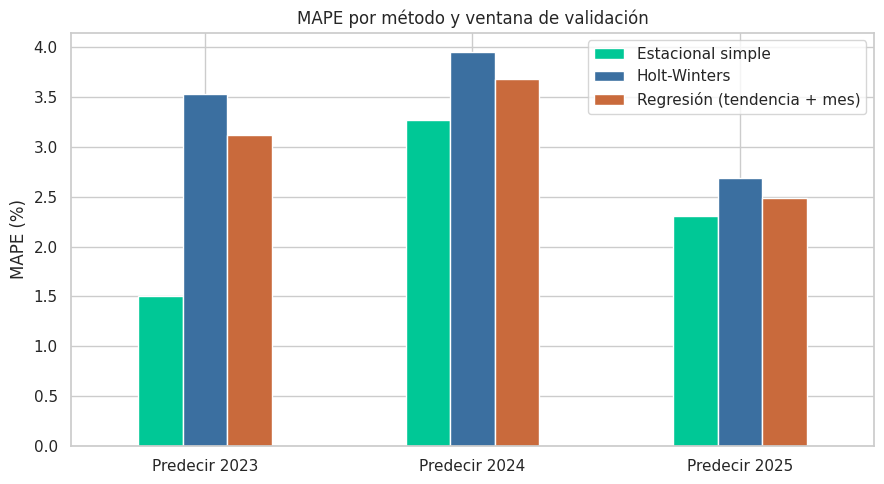

In [4]:
folds = [
    (monthly[monthly.index.year < 2023], monthly[monthly.index.year == 2023], "Predecir 2023"),
    (monthly[monthly.index.year < 2024], monthly[monthly.index.year == 2024], "Predecir 2024"),
    (monthly[monthly.index.year < 2025], monthly[monthly.index.year == 2025], "Predecir 2025"),
]

resultados = {"Estacional simple": [], "Holt-Winters": [], "Regresión (tendencia + mes)": []}
for train, test, _ in folds:
    start = test.index[0]
    resultados["Estacional simple"].append(mape(test.values, seasonal_naive_forecast(train, len(test), start)))
    resultados["Holt-Winters"].append(mape(test.values, holt_winters_forecast(train, len(test))))
    resultados["Regresión (tendencia + mes)"].append(mape(test.values, regression_forecast(train, len(test), start)))

df_backtest = pd.DataFrame(resultados, index=[f[2] for f in folds])
df_backtest.loc["Promedio"] = df_backtest.mean()
display(df_backtest.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
df_backtest.drop("Promedio").plot(kind="bar", ax=ax, color=["#00C896", "#3b6fa0", "#c96a3c"])
ax.set_title("MAPE por método y ventana de validación")
ax.set_ylabel("MAPE (%)")
ax.set_xticklabels(df_backtest.drop("Promedio").index, rotation=0)
plt.tight_layout()
plt.show()


**El modelo estacional simple es el más preciso de los tres, en las 3 ventanas de validación.**
Tiene sentido: la serie no muestra una tendencia de crecimiento o caída sostenida año a año (los montos
totales se mantienen muy estables), así que agregar un componente de tendencia (como hacen Holt-Winters
y la regresión) no aporta y a veces resta precisión. Se elige el **modelo estacional simple** por ser,
además, el más preciso, el más simple de explicar y de mantener.

## 4. Pronóstico por categoría (backtesting sobre 2025)

In [5]:
oi = pd.read_csv("../data/processed/order_items_clean.csv")
product = pd.read_csv("../data/processed/product_clean.csv")

oi_cat = oi.merge(product[["product_id", "product_category"]], on="product_id")
oi_cat = oi_cat.merge(sales[["order_id", "order_date"]], on="order_id")
oi_cat["month"] = oi_cat["order_date"].dt.to_period("M")

monthly_cat = oi_cat.groupby(["product_category", "month"])["net_sales"].sum().unstack("product_category").sort_index()
monthly_cat.index = monthly_cat.index.to_timestamp()

resultados_cat = []
for cat in monthly_cat.columns:
    serie = monthly_cat[cat].dropna()
    train_c = serie[serie.index.year < 2025]
    test_c = serie[serie.index.year == 2025]
    if len(test_c) == 0 or len(train_c) == 0:
        continue
    pred_c = seasonal_naive_forecast(train_c, len(test_c), test_c.index[0])
    resultados_cat.append({"categoría": cat, "MAPE (%)": mape(test_c.values, pred_c)})

df_cat_res = pd.DataFrame(resultados_cat).sort_values("MAPE (%)")
display(df_cat_res.round(2))
print(f"\nMAPE promedio entre las 15 categorías: {df_cat_res['MAPE (%)'].mean():.2f}%")


,categoría,MAPE (%)
6,Grocery,4.36
14,Toys & Games,5.29
3,Books & Media,5.89
10,Jewelry,5.94
9,Home Appliances,5.95
11,Office Supplies,6.01
1,Baby & Kids,6.11
7,Health & Wellness,6.46
2,Beauty & Personal Care,6.85
4,Electronics,6.87



MAPE promedio entre las 15 categorías: 6.40%


El modelo estacional simple funciona de forma consistente también a nivel de categoría — útil
para desagregar la planificación de inventario por línea de producto, no solo a nivel global.

## 5. Pronóstico a futuro: los próximos 12 meses

Con el método ya validado, se entrena con **todo el historial disponible** (2021-2025) y se
proyectan los 12 meses siguientes. La banda de incertidumbre se construye con la variabilidad histórica
observada para cada mes calendario (± 1 desvío estándar).

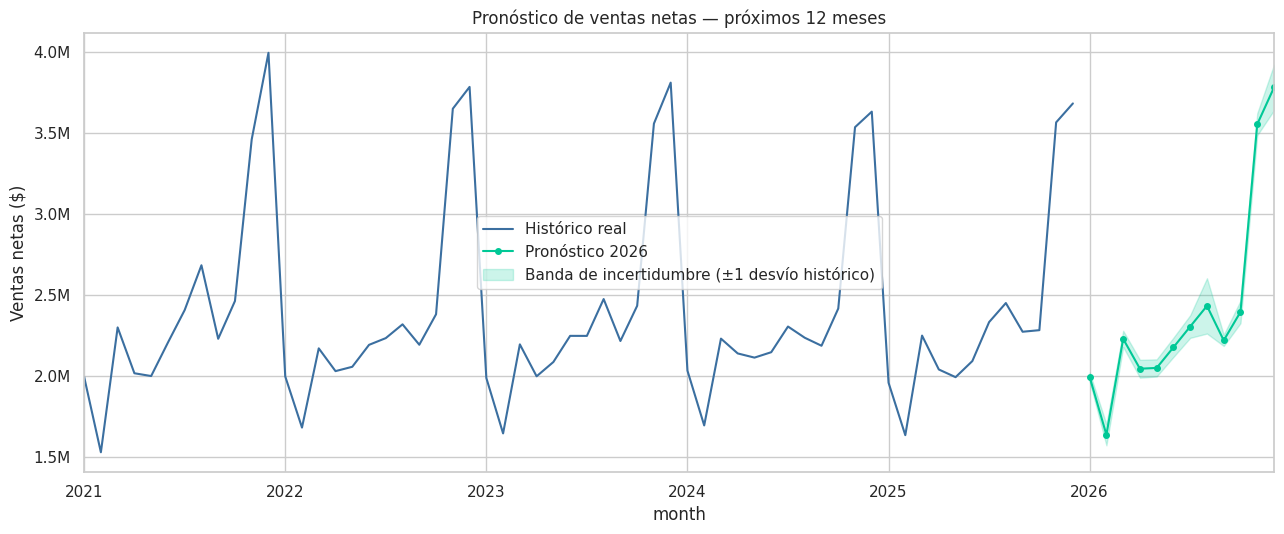

,pronóstico,banda_inferior,banda_superior
2026-01-01,1996372.0,1969752.0,2022992.0
2026-02-01,1639558.0,1574343.0,1704772.0
2026-03-01,2230895.0,2180978.0,2280812.0
2026-04-01,2046852.0,1991844.0,2101859.0
2026-05-01,2051757.0,1998892.0,2104622.0
2026-06-01,2178860.0,2119338.0,2238383.0
2026-07-01,2306933.0,2237115.0,2376751.0
2026-08-01,2434281.0,2263735.0,2604827.0
2026-09-01,2221465.0,2186943.0,2255986.0
2026-10-01,2396903.0,2327554.0,2466252.0


In [6]:
ultimo_mes = monthly.index.max()
horizonte = 12
meses_futuros = pd.date_range(ultimo_mes + pd.DateOffset(months=1), periods=horizonte, freq="MS")

stats_por_mes = monthly.groupby(monthly.index.month).agg(["mean", "std"])
pred_futura = np.array([stats_por_mes.loc[m.month, "mean"] for m in meses_futuros])
banda = np.array([stats_por_mes.loc[m.month, "std"] for m in meses_futuros])

forecast_df = pd.DataFrame({
    "pronóstico": pred_futura,
    "banda_inferior": pred_futura - banda,
    "banda_superior": pred_futura + banda,
}, index=meses_futuros)

fig, ax = plt.subplots(figsize=(13, 5.5))
monthly.plot(ax=ax, color="#3b6fa0", label="Histórico real")
forecast_df["pronóstico"].plot(ax=ax, color="#00C896", marker="o", markersize=4, label="Pronóstico 2026")
ax.fill_between(forecast_df.index, forecast_df["banda_inferior"], forecast_df["banda_superior"],
                color="#00C896", alpha=0.2, label="Banda de incertidumbre (±1 desvío histórico)")
ax.set_title("Pronóstico de ventas netas — próximos 12 meses")
ax.set_ylabel("Ventas netas ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

display(forecast_df.round(0))


## 6. Recomendaciones de negocio

- **Adoptar el modelo estacional simple** como pronóstico oficial de demanda: es el más preciso de los
  tres métodos evaluados (2.36% de error promedio en backtesting de 3 años, frente a 3.39% de
  Holt-Winters y 3.09% de la regresión con tendencia), y el más simple de mantener y explicar a
  cualquier área del negocio.
- **Anticipar la temporada alta (noviembre-diciembre)**: el pronóstico proyecta un salto de
  aproximadamente 48%-57% sobre un mes típico — clave para decisiones de stock, dotación de personal
  temporal y flujo de caja con la antelación suficiente.
- **Desagregar por categoría** para la planificación de compras: el mismo método funciona categoría por
  categoría (4%-8% de error, 6.40% en promedio entre las 15 categorías), permitiendo ajustar inventario
  específico en vez de solo un número global.
- **Actualizar el pronóstico mensualmente**: a medida que se sume cada mes real, conviene re-entrenar el
  promedio histórico por mes calendario — el método es liviano computacionalmente y no requiere
  reentrenamientos complejos.
- **Próximo paso sugerido**: extender el mismo enfoque a nivel de sucursal/región, si el negocio necesita
  planificación logística más granular que la categoría de producto.